In [36]:
import os
import pandas as pd
import seaborn as sns
from config import DATA_CLEAN, OUTPUTS
import matplotlib.pyplot as plt

out = os.path.join(DATA_CLEAN, "yearly_clean.csv")

df = pd.read_csv(out)

In [12]:
features = [
    ("growing_season_rainfall_mm",   "Rainfall (mm)",           "#2E86AB"),
    ("growing_season_solar_kwh_m2",  "Solar (kWh/m²/day)",      "#F29E4C"),
    ("wheat_area_ha",                "Area harvested (Mha)",    "#7FB069"),
    ("wheat_yield_kg_ha",            "Yield (kg/ha)",           "#8B1E3F"),
    ("wheat_production_t",           "Production (Mt)",         "#6A4C93"),
]


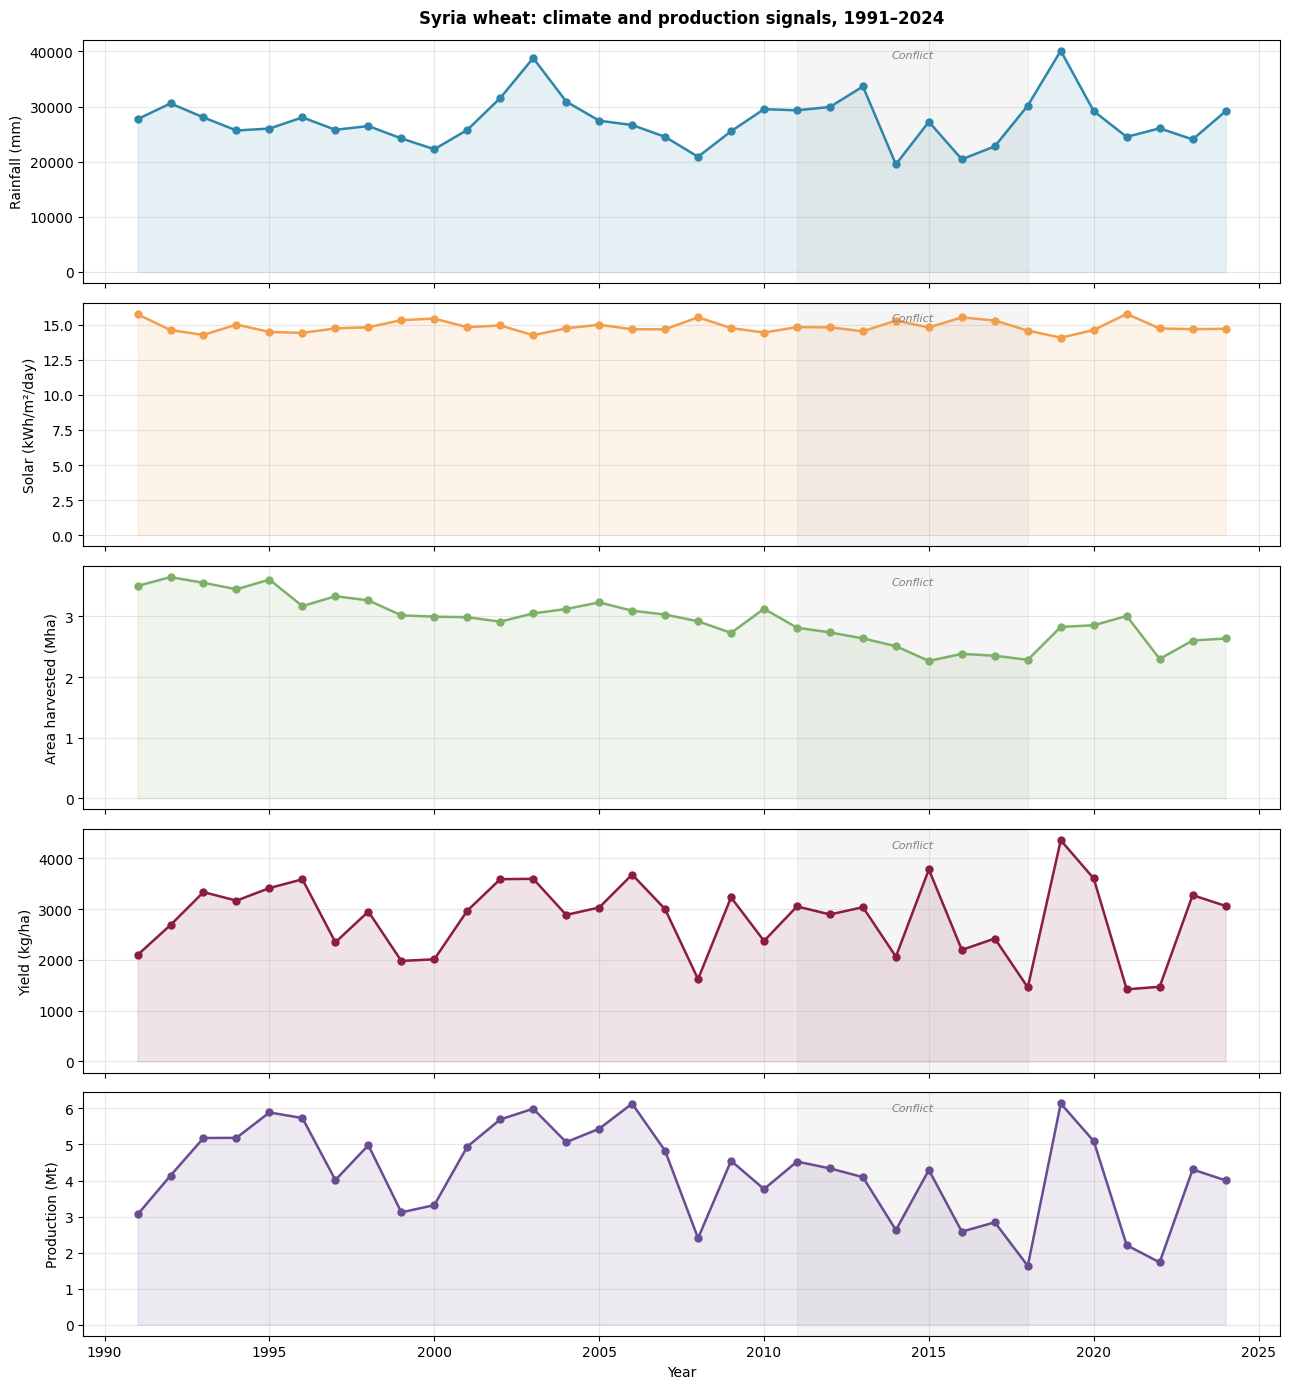

In [37]:
fig, axes = plt.subplots(5, 1, figsize=(13, 14), sharex=True)

for ax, (col, label, color) in zip(axes, features):
    y = df[col]
    if "area_ha" in col:
        y = y / 1e6
        unit = "Mha"
    elif "production_t" in col:
        y = y / 1e6
        unit = "Mt"
    else:
        unit = ""

    ax.plot(df["year"], y, marker="o", linewidth=1.8,
            markersize=5, color=color)
    ax.fill_between(df["year"], y, alpha=0.12, color=color)
    ax.axvspan(2011, 2018, alpha=0.08, color="grey")
    ax.text(2014.5, ax.get_ylim()[1] * 0.92, "Conflict",
            ha="center", fontsize=8, color="grey", style="italic")
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Year")
axes[0].set_title("Syria wheat: climate and production signals, 1991–2024",
                  fontweight="bold", pad=12)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, "timeseries_all.png"), bbox_inches="tight")
plt.show()

C:\Users\MK1349\AppData\Local\Temp\ipykernel_9460\2247330107.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="era", y=col, ax=ax, palette="Blues")
C:\Users\MK1349\AppData\Local\Temp\ipykernel_9460\2247330107.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="era", y=col, ax=ax, palette="Blues")
C:\Users\MK1349\AppData\Local\Temp\ipykernel_9460\2247330107.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="era", y=col, ax=ax, palette="Blues")
C:\Users\MK1349\AppData\Local\Temp\ipykernel_9460\2247330107.

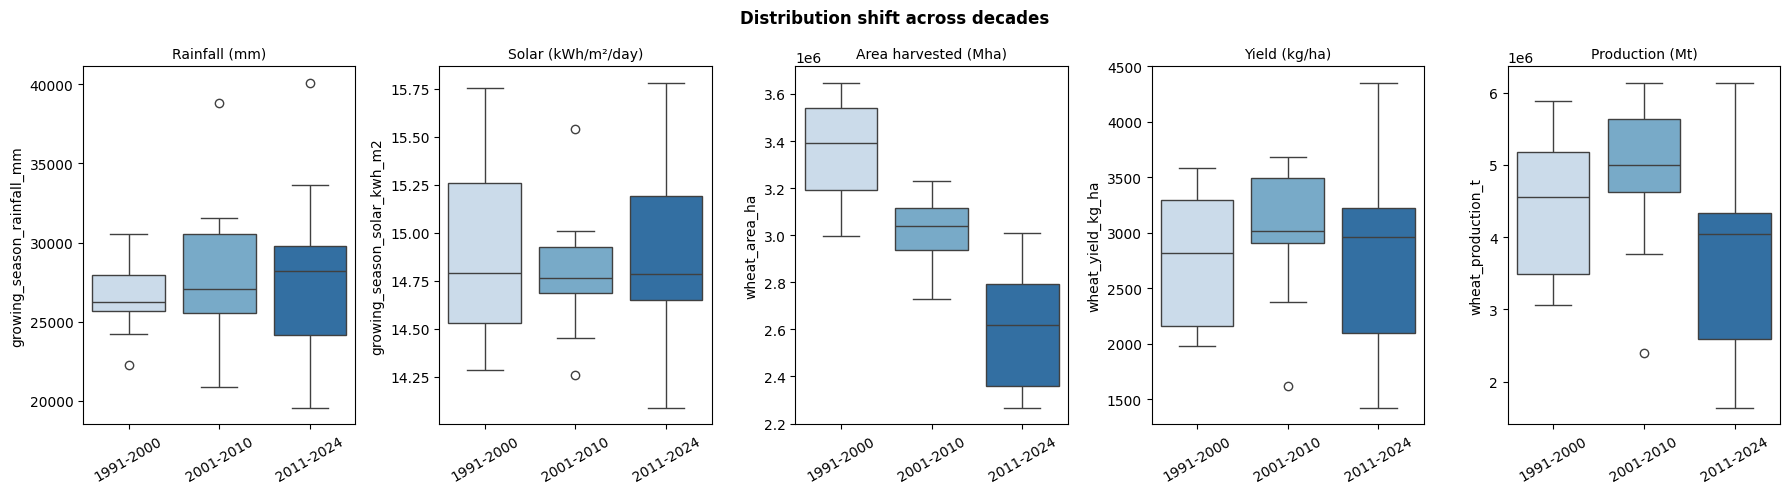

In [38]:
df["era"] = pd.cut(df["year"],
                       bins=[1990, 2000, 2010, 2024],
                       labels=["1991-2000", "2001-2010", "2011-2024"])

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, (col, label, _) in zip(axes, features):
    sns.boxplot(data=df, x="era", y=col, ax=ax, palette="Blues")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    

plt.suptitle("Distribution shift across decades", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, "distributions_by_era.png"), bbox_inches="tight")
plt.show()

## Correlation heatmap (5×5)
Purpose: one image that shows every pairwise relationship at once.

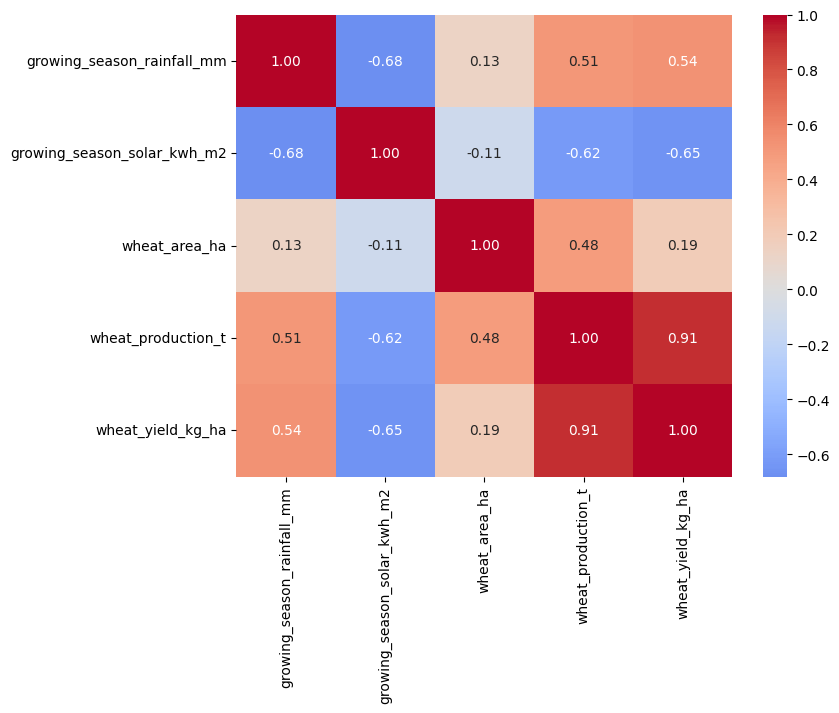

In [40]:
cols = ["growing_season_rainfall_mm", "growing_season_solar_kwh_m2",
        "wheat_area_ha", "wheat_production_t", "wheat_yield_kg_ha"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.savefig(os.path.join(OUTPUTS, "corr_heatmap.png"), dpi=200, bbox_inches="tight")
plt.show()

| Pair | r | Significant? | Interpretation |
|---|---|---|---|
| Rainfall ↔ Solar | **−0.68** | Yes | Strong negative — clear-sky years are dry years |
| Rainfall ↔ Area | **+0.13** | NO | Negligible — planting decisions not driven by weather |
| Rainfall ↔ Production | **+0.51** | Yes | Moderate positive — drought hurts output |
| Rainfall ↔ Yield | **+0.54** | Yes | Moderate positive — drought hurts yield per hectare |
| Solar ↔ Area | **−0.11** | NO | Negligible |
| Solar ↔ Production | **−0.62** | Yes | Strong negative — sunny years produce less |
| Solar ↔ Yield | **−0.65** | Yes | Strong negative — sunny years have lower yields |
| Area ↔ Production | **+0.48** | Yes | Moderate positive — more land = more wheat |
| Area ↔ Yield | **+0.19** | NO | Weak — planted area and yield are fairly independent |
| Production ↔ Yield | **+0.91** | Yes | Very strong — production tracks yield tightly |
